C 0 4 3 1
C 1 4 3 1
C 2 4 3 1
C 3 4 3 1
C 4 4 3 1
C 5 4 4 0
C 6 4 4 0
O 7 2 2 0
O 8 2 1 1
AROMATIC 0 1
AROMATIC 1 2
AROMATIC 2 3
AROMATIC 3 4
AROMATIC 4 5
SINGLE 5 6
DOUBLE 6 7
SINGLE 6 8
AROMATIC 5 0


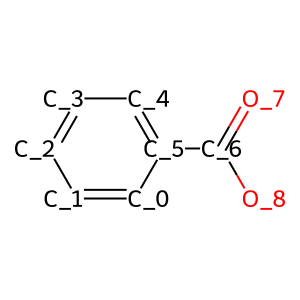

In [173]:
from datasets import load_from_disk
from rdkit import Chem
import selfies as sf
from data_utils import prepare_rejected_input_mol_string
from rdkit.Chem import Draw
from data_utils import mol2graph, graph2data
import numpy as np
import copy
import re
from tqdm import tqdm

a = "c1ccccc1C(=O)O"
mol = Chem.MolFromSmiles(a)
#Chem.Kekulize(mol)
mol = Chem.RWMol(mol)
#mol.RemoveBond(0, 1)
#mol.AddBond(0, 1, Chem.rdchem.BondType.SINGLE)
atoms = mol.GetAtoms()
bonds = mol.GetBonds()

for atom in atoms:
    print(atom.GetSymbol(), atom.GetIdx(), atom.GetTotalValence(), atom.GetExplicitValence(), atom.GetImplicitValence())

for bond in bonds:
    print(bond.GetBondType(), bond.GetBeginAtomIdx(), bond.GetEndAtomIdx())

for atom in mol.GetAtoms():
    # get initial atom label
    atom.SetProp("atomLabel", atom.GetSymbol() + "_" + str(atom.GetIdx()))  # Use atom index as label

# Draw the molecule
Draw.MolToImage(mol)

[06:58:08] Explicit valence for atom # 3 Sn, 6, is greater than permitted


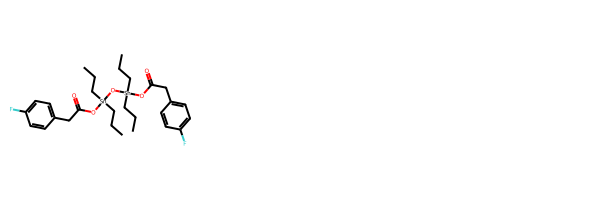

In [179]:
origin_selfies = '[C][C][C][Sn][Branch1][Ring2][C][C][C][Branch2][Ring1][C][O][C][=Branch1][C][=O][C][C][=C][C][=C][Branch1][C][F][C][=C][Ring1][#Branch1][O][Sn][Branch1][Ring2][C][C][C][Branch1][Ring2][C][C][C][O][C][=Branch1][C][=O][C][C][=C][C][=C][Branch1][C][F][C][=C][Ring1][#Branch1]'
origin_smiles = sf.decoder(origin_selfies)
origin_mol = Chem.MolFromSmiles(origin_smiles)
Chem.SanitizeMol(origin_mol)
problematic_selfies = '[C][C][C][Sn][Branch1][Ring2][C][C][C][Branch2][Ring1][C][O][C][=Branch1][C][=O][C][C][=C][C][=C][Branch1][C][C][=C][Ring1][#Branch1][Sn][Branch1][Ring2][C][C][C][Branch1][Ring2][C][C][C][O][C][=Branch1][C][=O][C][C][=C][C][=C][Branch1][C][F][C][=C][Ring1][#Branch1]'
problematic_smiles = sf.decoder(problematic_selfies)    
problematic_mol = Chem.MolFromSmiles(problematic_smiles)

Draw.MolsToGridImage([origin_mol, problematic_mol])

mol <rdkit.Chem.rdchem.Mol object at 0x7f7d0d609540>
original_num_atoms 37
augmeted_num_atoms 50
num_not_fulfilled_changes 0


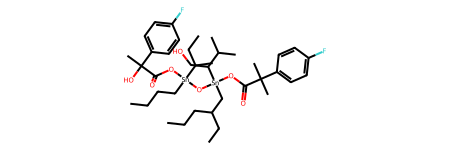

In [183]:
out = augment_molecular_size_based_on_mol(origin_mol)
for k in out:
    print(k, out[k])
out['mol']